# Quick Intro

It is possible to introduce neural networks without relying on brain analogies.

In the linear classification setting, we computed scores for different visual categories using:

$$
s = Wx
$$

Here:

- $W$ is a weight matrix  
- $x$ is an input column vector containing all pixel values of the image  

For example, in the CIFAR-10 dataset:

- $x \in \mathbb{R}^{3072 \times 1}$  
- $W \in \mathbb{R}^{10 \times 3072}$  

This produces:

- $s \in \mathbb{R}^{10 \times 1}$ → a vector of class scores  

---

## Two-Layer Neural Network

A simple neural network extends this computation as:

$$
s = W_2 \max(0, W_1 x)
$$

Where:

- $W_1 \in \mathbb{R}^{100 \times 3072}$ transforms the input into a hidden representation  
- $\max(0, \cdot)$ is a non-linear activation function (ReLU)  
- $W_2 \in \mathbb{R}^{10 \times 100}$ maps to class scores  

# Modeling One Neuron

The field of Neural Networks was originally inspired by attempts to model biological neural systems. However, over time it has evolved into more of an engineering discipline focused on achieving strong performance in Machine Learning tasks.

Still, it is useful to briefly understand the biological motivation behind neural networks.

---

## Biological Motivation and Connections

The fundamental computational unit of the brain is the **neuron**.

- The human nervous system contains approximately $86$ billion neurons  
- These neurons are connected through roughly $10^{14}$ to $10^{15}$ synapses  

Each biological neuron:

- Receives input signals through **dendrites**
- Processes them in the **cell body**
- Produces output signals along a single **axon**
- Connects to other neurons via **synapses**

---

## Computational Model of a Neuron

In the mathematical abstraction:

- Inputs: $x_0, x_1, \dots, x_n$  
- Weights (synaptic strengths): $w_0, w_1, \dots, w_n$  

Each input interacts multiplicatively with its corresponding weight:

$$
w_i x_i
$$

All inputs are summed together along with a bias term:

$$
\sum_i w_i x_i + b
$$

### Interpretation of Weights

- Positive weights → **excitatory effect**  
- Negative weights → **inhibitory effect**  

---

## Activation and Firing Rate

If the total input exceeds a certain threshold, the neuron "fires".

In computational models:

- Exact spike timing is ignored  
- Only the **firing rate** is modeled  

This is captured using an activation function:

$$
f\left(\sum_i w_i x_i + b\right)
$$

---

## Sigmoid Activation Function

A historically popular choice is the **sigmoid function**:

$$
\sigma(x) = \frac{1}{1 + e^{-x}}
$$

Properties:

- Maps real values to the range $(0, 1)$  
- Can be interpreted as a probability  

---

## Example: Forward Pass of a Single Neuron



In [4]:

import numpy as np
import math

class Neuron(object):
    def __init__(self, weights, bias):
        self.weights = weights
        self.bias = bias

    def forward(self, inputs):
        """
        inputs: 1-D numpy array
        weights: 1-D numpy array
        bias: scalar
        """
        cell_body_sum = np.sum(inputs * self.weights) + self.bias
        firing_rate = 1.0 / (1.0 + math.exp(-cell_body_sum))  # sigmoid activation
        return firing_rate

# Commonly Used Activation Functions

An activation function (or non-linearity) takes a single number and applies a fixed mathematical transformation to it.

Several activation functions are commonly used in practice.

---

## Sigmoid

The sigmoid function is defined as:

$$
\sigma(x) = \frac{1}{1 + e^{-x}}
$$

It maps real-valued inputs into the range $(0, 1)$.

- Large negative values → close to $0$  
- Large positive values → close to $1$  

### Drawbacks

- **Saturation problem** → gradients become very small  
- **Not zero-centered** → slows down optimization  

Because of these issues, sigmoid is rarely used in modern neural networks.


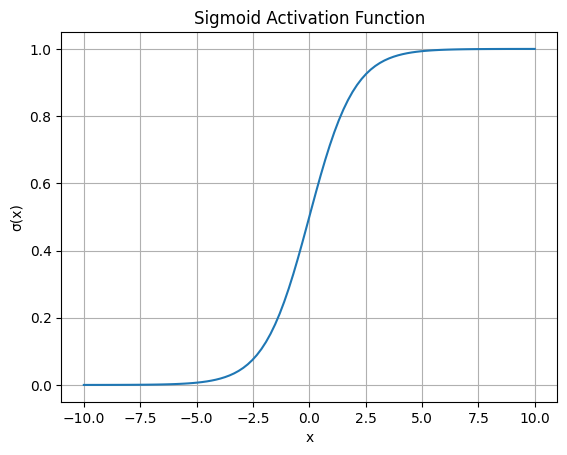

In [3]:
# Sigmoid activation visualization

import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-10, 10, 100)
sigmoid = 1 / (1 + np.exp(-x))

plt.plot(x, sigmoid)
plt.title("Sigmoid Activation Function")
plt.xlabel("x")
plt.ylabel("σ(x)")
plt.grid()
plt.show()

## Tanh

The tanh function is defined as:

$$
\tanh(x) = \frac{e^x - e^{-x}}{e^x + e^{-x}}
$$

It maps inputs into the range $(-1, 1)$.

### Properties

- Zero-centered  
- Still suffers from saturation  

Relation to sigmoid:

$$
\tanh(x) = 2\sigma(2x) - 1
$$

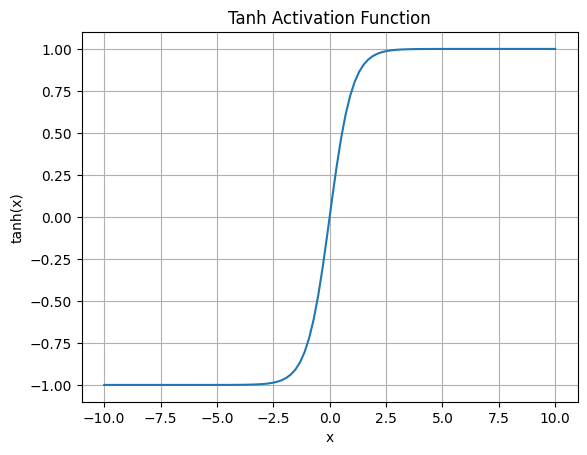

In [4]:
# Tanh activation visualization

x = np.linspace(-10, 10, 100)
tanh = np.tanh(x)

plt.plot(x, tanh)
plt.title("Tanh Activation Function")
plt.xlabel("x")
plt.ylabel("tanh(x)")
plt.grid()
plt.show()

## ReLU (Rectified Linear Unit)

ReLU is defined as:

$$
f(x) = \max(0, x)
$$

### Advantages

- Fast computation  
- Does not saturate for positive values  
- Accelerates training  

### Disadvantages

- "Dying ReLU" problem → neurons can stop activating permanently  

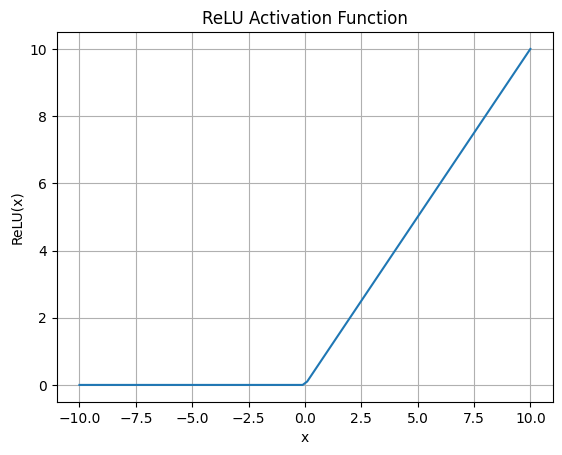

In [5]:
# ReLU activation visualization

x = np.linspace(-10, 10, 100)
relu = np.maximum(0, x)

plt.plot(x, relu)
plt.title("ReLU Activation Function")
plt.xlabel("x")
plt.ylabel("ReLU(x)")
plt.grid()
plt.show()

## Leaky ReLU

Leaky ReLU fixes the dying ReLU problem by allowing a small slope for negative values:

$$
f(x) =
\begin{cases}
x & x \geq 0 \\
\alpha x & x < 0
\end{cases}
$$

Where $\alpha$ is a small constant (e.g., $0.01$).

### Properties

- Prevents neurons from dying  
- Slightly improves gradient flow  

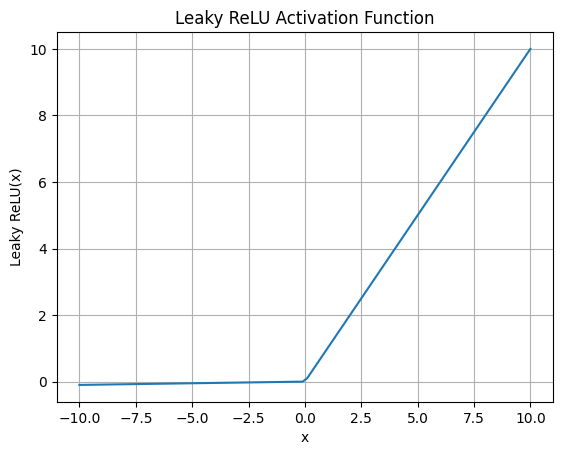

In [6]:
# Leaky ReLU activation visualization

x = np.linspace(-10, 10, 100)
alpha = 0.01 # change alpha for see diffirence between ReLU and Leaky ReLU
leaky_relu = np.where(x > 0, x, alpha * x)

plt.plot(x, leaky_relu)
plt.title("Leaky ReLU Activation Function")
plt.xlabel("x")
plt.ylabel("Leaky ReLU(x)")
plt.grid()
plt.show()

## Maxout

Maxout is defined as:

$$
f(x) = \max(w_1^T x + b_1,\; w_2^T x + b_2)
$$

### Properties

- Generalizes ReLU and Leaky ReLU  
- No saturation  
- Avoids dying ReLU problem  

### Drawback

- Doubles the number of parameters  

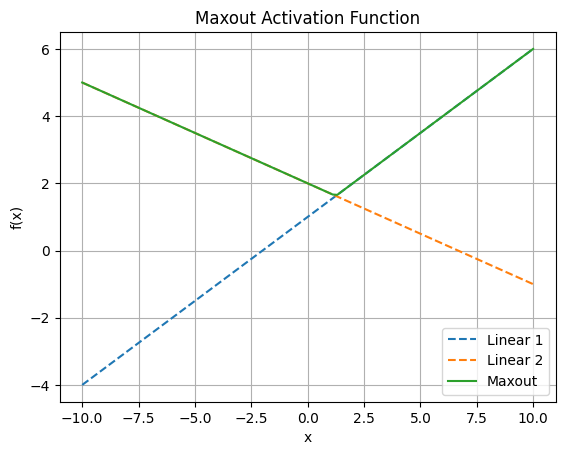

In [7]:
# Maxout visualization (simplified 1D example)

x = np.linspace(-10, 10, 100)

# Two linear functions
y1 = 0.5 * x + 1
y2 = -0.3 * x + 2

maxout = np.maximum(y1, y2)

plt.plot(x, y1, linestyle='--', label='Linear 1')
plt.plot(x, y2, linestyle='--', label='Linear 2')
plt.plot(x, maxout, label='Maxout')
plt.title("Maxout Activation Function")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.legend()
plt.grid()
plt.show()


## Summary

- **Sigmoid** → rarely used (saturation + not zero-centered)  
- **Tanh** → better than sigmoid but still saturates  
- **ReLU** → default choice in most cases  
- **Leaky ReLU** → safer alternative to ReLU  
- **Maxout** → powerful but computationally expensive  


- Use **ReLU** as default  
- Monitor dead neurons  
- Try **Leaky ReLU** or **Maxout** if needed  
- Avoid **sigmoid**  

# Neural Network Architectures

---

## Layer-wise Organization

### Neural Networks as Graphs

Neural Networks can be viewed as collections of neurons connected in an **acyclic graph**.

- Outputs of some neurons become inputs to others  
- Cycles are **not allowed** (to avoid infinite loops in forward pass)  

Instead of arbitrary connections, networks are typically organized into **layers**.

---

## Fully-Connected Layers

The most common layer type is the **fully-connected (dense) layer**:

- Every neuron in one layer is connected to **every neuron in the next layer**
- No connections exist **within the same layer**

---

## Example Architectures

Below are two example neural network architectures:
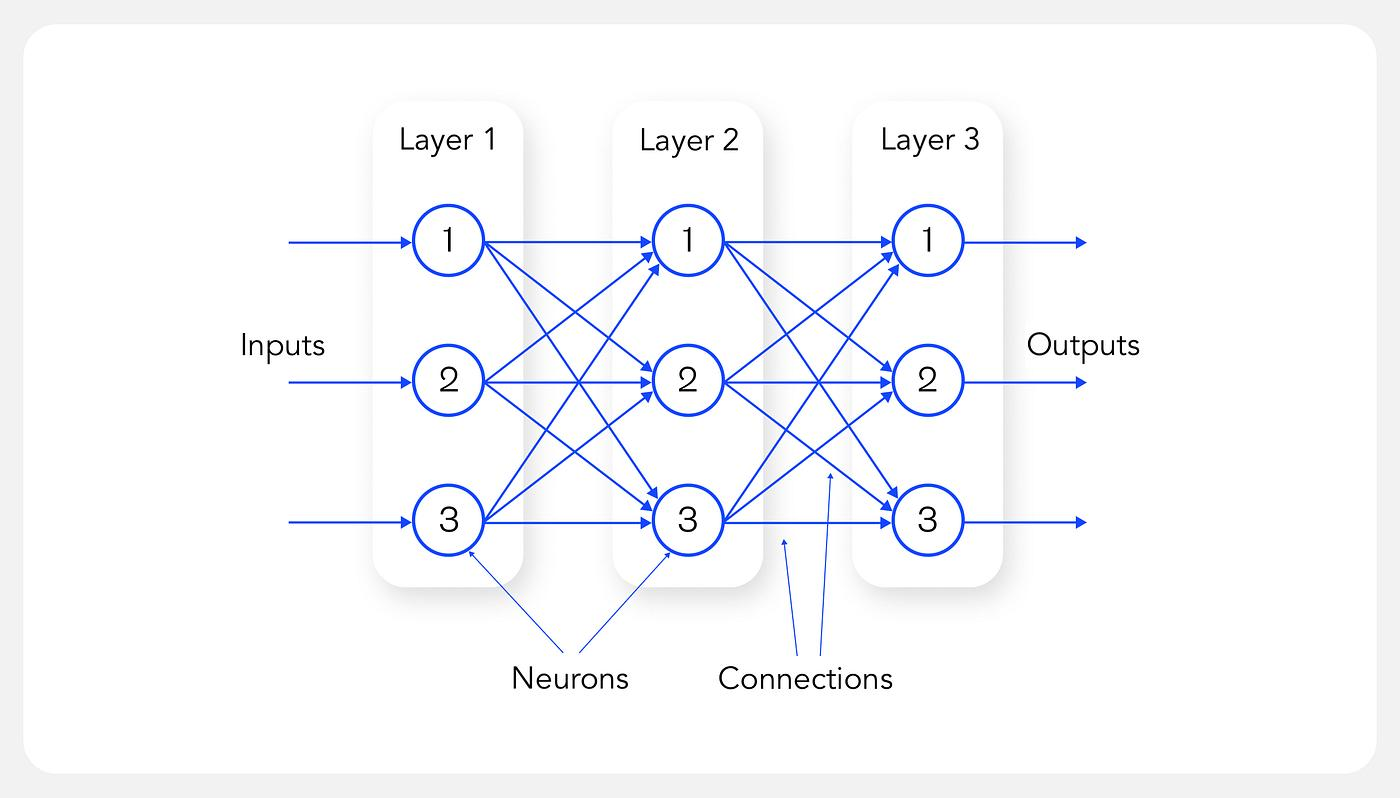

Notice:

- Connections exist **between layers**
- No connections exist **within a layer**

---

## Naming Conventions

- An **N-layer network does NOT include the input layer**
- Examples:
  - 1-layer network → no hidden layer  
  - Logistic regression = special case of neural network  

Other names:

- **ANN (Artificial Neural Network)**  
- **MLP (Multi-Layer Perceptron)**  

---

## Output Layer

The output layer usually:

- Has **no activation function**
- Uses **linear output**

Why?

- Outputs represent:
  - Class scores (classification)
  - Real values (regression)

---

## Network Size

Two common ways to measure size:

1. Number of neurons  
2. Number of parameters (**more important**)  

## Modern Networks

- Modern CNNs can have:
  - $\sim 10^8$ parameters  
  - $10$–$20$ layers  

---

# Example: Feed-Forward Computation

---

## Matrix-Based Computation

Neural networks are efficient because they use:

- Matrix multiplications  
- Vectorized operations  

For a 3-layer network:

- Input: $x \in \mathbb{R}^{3 \times 1}$  
- $W_1 \in \mathbb{R}^{4 \times 3}$  
- $W_2 \in \mathbb{R}^{4 \times 4}$  
- $W_3 \in \mathbb{R}^{1 \times 4}$  

---

## Forward Pass Formula

$$
h_1 = f(W_1 x + b_1)
$$

$$
h_2 = f(W_2 h_1 + b_2)
$$

$$
\text{out} = W_3 h_2 + b_3
$$

---

## Implementation



In [12]:

def f(x):
    """
    Sigmoid activation function
    """
    return 1.0 / (1.0 + np.exp(-x))
# weights
W1 = np.random.randn(4, 3)  # (4x3)
W2 = np.random.randn(4, 4)  # (4x4)
W3 = np.random.randn(1, 4)  # (1x4)

# biases
b1 = np.random.randn(4, 1)  # (4x1)
b2 = np.random.randn(4, 1)  # (4x1)
b3 = np.random.randn(1, 1)  # (1x1)
## Forward Pass Implementation

# random input (3x1)
x = np.random.randn(3, 1)

# assume parameters are already initialized
h1 = f(np.dot(W1, x) + b1)  # first hidden layer (4x1)
h2 = f(np.dot(W2, h1) + b2) # second hidden layer (4x1)
out = np.dot(W3, h2) + b3   # output layer (1x1)

print(out)

[[0.74145655]]


# Setting Number of Layers and Their Sizes

---

## Model Capacity

When designing a neural network, a key question is:

- How many layers should we use?
- How many neurons per layer?

As we increase:

- Number of layers  
- Number of neurons  

the **capacity** of the network increases.

### What is Capacity?

Capacity refers to the ability of a network to represent complex functions.

---

## Example: Decision Boundaries

Below are neural networks with increasing size trained on the same dataset:
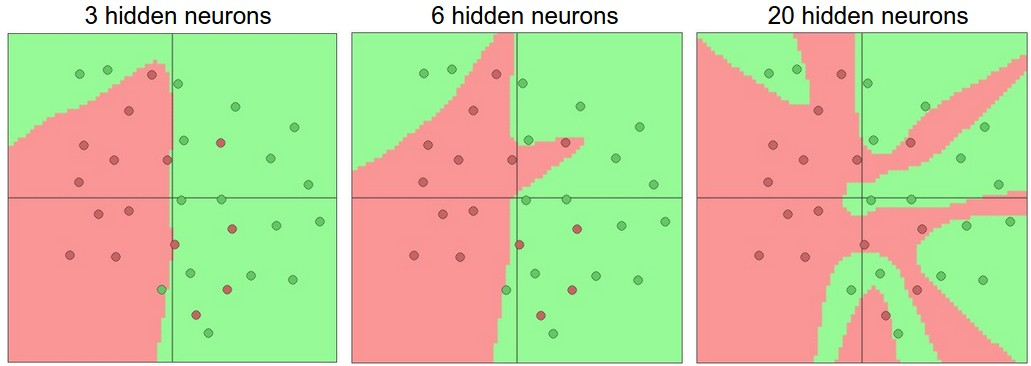

- Small network → simple decision boundary  
- Large network → complex decision boundary  

---

## Overfitting vs Generalization

Larger networks can model more complex patterns, but:

- ✅ **Advantage** → can fit complicated data  
- ❌ **Disadvantage** → can overfit  

### What is Overfitting?

Overfitting happens when:

- The model learns **noise instead of true patterns**
- Decision boundary becomes overly complex  

Example:

- 20 neurons → fits every training point → complex fragmented regions  
- 3 neurons → simpler boundary → ignores noise → better generalization  

---

## Should We Use Smaller Networks?

At first glance, it might seem logical:

> "Use smaller networks to avoid overfitting"

However, this is **not the best strategy**.

---

## Better Approach: Regularization

Instead of reducing network size, we use:

- L2 regularization  
- Dropout  
- Input noise  

These techniques control overfitting more effectively.

---

## Optimization Perspective

Why not use smaller networks?

- Small networks:
  - Fewer local minima  
  - But many are **bad minima** (high loss)  

- Large networks:
  - More local minima  
  - But many are **good solutions**  

### Key Insight

- Small networks → training is unstable  
- Large networks → more consistent results  

---

## Variance in Training

- Small network:
  - High variance in final loss  
  - Depends heavily on initialization  

- Large network:
  - Low variance  
  - Most solutions perform similarly  

---

## Effect of Regularization

Below, the same network is trained with different regularization strengths:
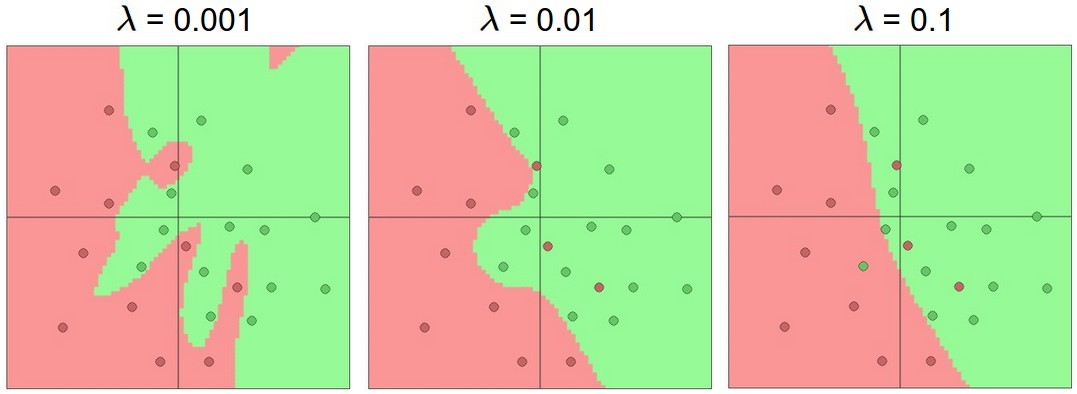

- Weak regularization → complex boundary  
- Strong regularization → smoother boundary  

---

## Final Takeaway

- Do NOT reduce network size to prevent overfitting  
- Use **larger networks** when possible  
- Control overfitting with **regularization techniques**  

- Bigger networks = more capacity  
- Overfitting is controlled by **regularization**, not size  
- Use the largest model your compute allows  